# Visualize conditional flow-matching model

In [1]:
import sys
import os

# Adds the parent directory to python path
root_dir_path = os.path.abspath('..')
sys.path.append(root_dir_path)

In [2]:
import yaml
import matplotlib.pyplot as plt
import numpy as np
import random

import torch
import torchvision
import torchvision.transforms as transforms

import data
from models import get_model
from utils import flow_matching_utils as fm_utils
from utils import fid_utils, log_utils

In [3]:
exp_dir = os.path.join(root_dir_path, "checkpoints", "exp_001")

exp_config_path = os.path.join(exp_dir, "config.yml")

ckpt_path = os.path.join(exp_dir, "checkpoint_latest.pt")

with open(exp_config_path) as fp:
    exp_config = yaml.safe_load(fp)

In [4]:
def get_device() -> torch.device:
    """Automatically detect available device"""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    else:
        return torch.device("cpu")

torch_device = get_device()
print(torch_device)

xpu


In [5]:
dataset_name = exp_config["dataset"]["name"]
num_classes = data.get_num_classes_from_dataset(dataset_name)
test_dataloader = data.get_test_dataloader(dataset_name, batch_size=32, num_workers=8)
val_imgsize = exp_config["dataset"]["val"]["imgsize"]

c:\Users\megaa\miniconda3\envs\pt3.13\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
model_config = exp_config["model"]
model_arch = model_config["arch"]
model_params = model_config.get("params", dict())

model = get_model(
    model_arch=model_arch,
    model_params=model_params,
    c_in=3,
    num_classes=num_classes,
)

model_state = torch.load(ckpt_path)["model_state"]
model.load_state_dict(model_state)

<All keys matched successfully>

In [7]:
model.eval()
model = model.to(torch_device)

In [8]:
# Function to show images with CLS labels
def imshow(img):
    """Display a single image and its label."""
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

def show_image_grid(images, labels):
    """
    Display a grid of images with their corresponding labels.
    
    Args:
        images: Tensor of shape (N, C, H, W) or list of (C, H, W)
        labels: List of label strings
    """
    fig, axes = plt.subplots(4, 5, figsize=(10, 6))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i]
            label = labels[i] if isinstance(labels, list) else labels[i].item()
            ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
            ax.set_title(label)
            ax.axis('off')
        else:
            ax.axis('off')
    plt.tight_layout()
    plt.show()

In [9]:
SAMPLE_NFE_EVALS = 20

euler_solver = fm_utils.EulerSolver(num_steps=SAMPLE_NFE_EVALS)
dpmp_solver_linear = fm_utils.DPMPSolver(num_steps=SAMPLE_NFE_EVALS, schedule="linear")
dpmp_solver_cosine = fm_utils.DPMPSolver(num_steps=SAMPLE_NFE_EVALS, schedule="cosine")
dpmp_solver_quadratic = fm_utils.DPMPSolver(num_steps=SAMPLE_NFE_EVALS, schedule="quadratic")

In [10]:
dataset_classes = test_dataloader.dataset.classes # type: ignore
cls_to_idx = test_dataloader.dataset.class_to_idx # type: ignore

print(dataset_classes)
print(cls_to_idx)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [11]:
def gen_and_plot_sample_imgs(model, solver, classes, cls_to_idx, cfg_scale=2.0, n_samples: int = 20):
    if len(classes) > n_samples:
        cls_list = random.sample(classes, k=n_samples)
        cls_list.sort()
    else:
        classes.sort()
        cls_list = list()
        s_ratio = n_samples // len(classes)
        for ii in range(n_samples):
            cls_idx = ii // s_ratio
            cls_list.append(classes[cls_idx])

    cls_idx_list = [cls_to_idx[x] for x in cls_list]

    samples_list = list()
    for ii in range(n_samples):
        cls_tensor = torch.tensor(cls_idx_list[ii], dtype=torch.long, device=torch_device)[None]
        shape = (1, 3, val_imgsize, val_imgsize)
        sample = solver.sample(
            model=model,
            shape=shape,
            cls=cls_tensor,
            device=torch_device,
            cfg_scale=cfg_scale,
        )
        sample = torch.clip(sample, 0.0, 1.0)
        samples_list.append(sample[0, ...].detach().cpu())

    show_image_grid(samples_list, cls_list)

In [12]:
_SAMPLE_CFG_SCALE = 4.0
_NUM_SAMPLES = 20

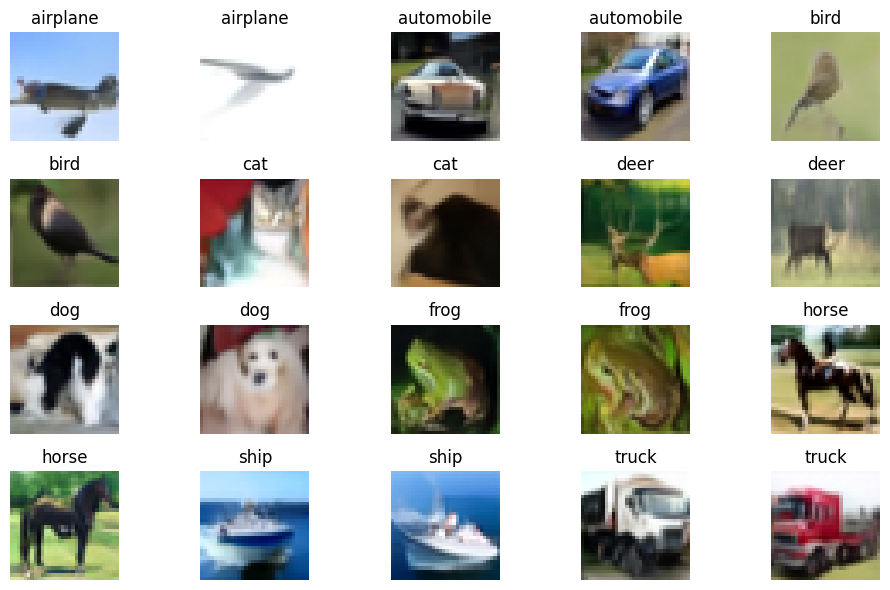

In [13]:
gen_and_plot_sample_imgs(
    model, euler_solver, dataset_classes, cls_to_idx, _SAMPLE_CFG_SCALE, _NUM_SAMPLES
)

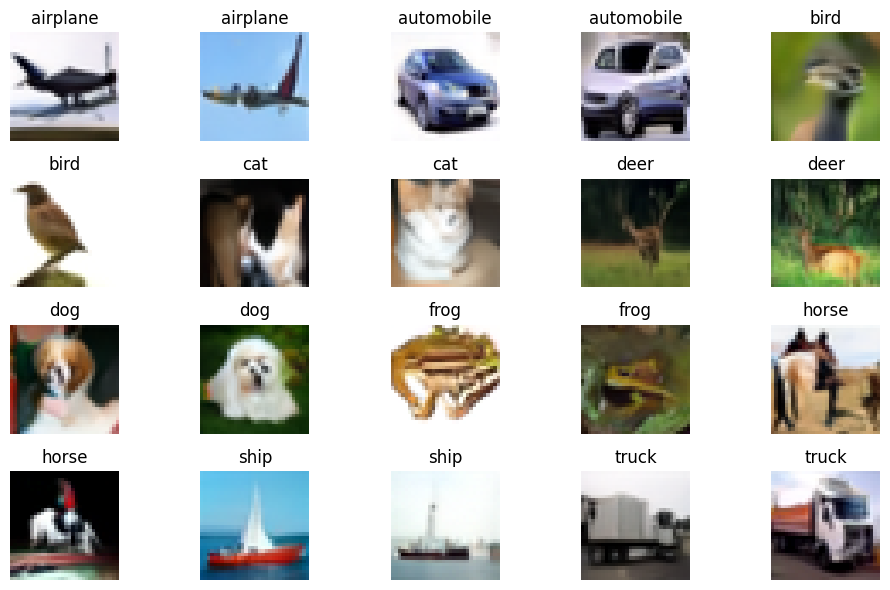

In [14]:
gen_and_plot_sample_imgs(
    model,
    dpmp_solver_linear,
    dataset_classes,
    cls_to_idx,
    _SAMPLE_CFG_SCALE,
    _NUM_SAMPLES,
)

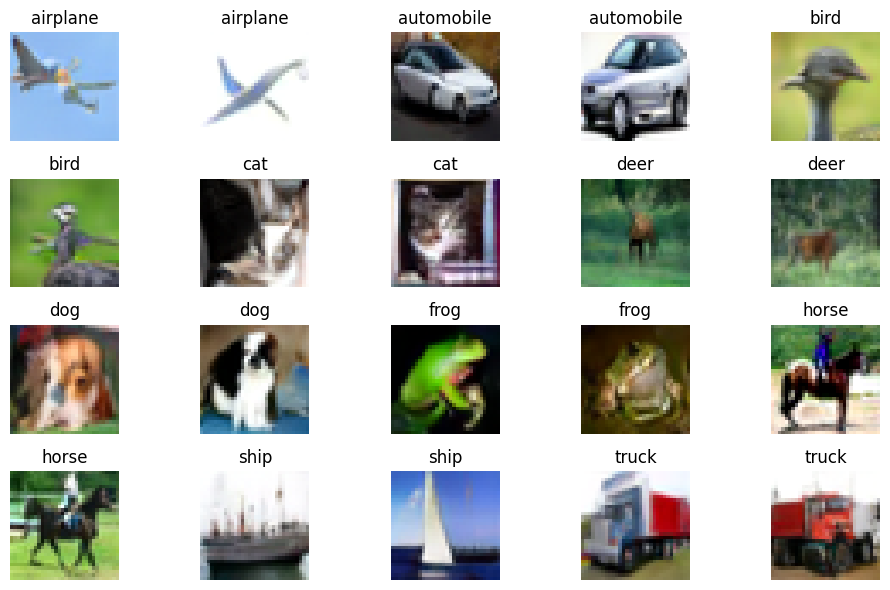

In [15]:
gen_and_plot_sample_imgs(
    model,
    dpmp_solver_cosine,
    dataset_classes,
    cls_to_idx,
    _SAMPLE_CFG_SCALE,
    _NUM_SAMPLES,
)

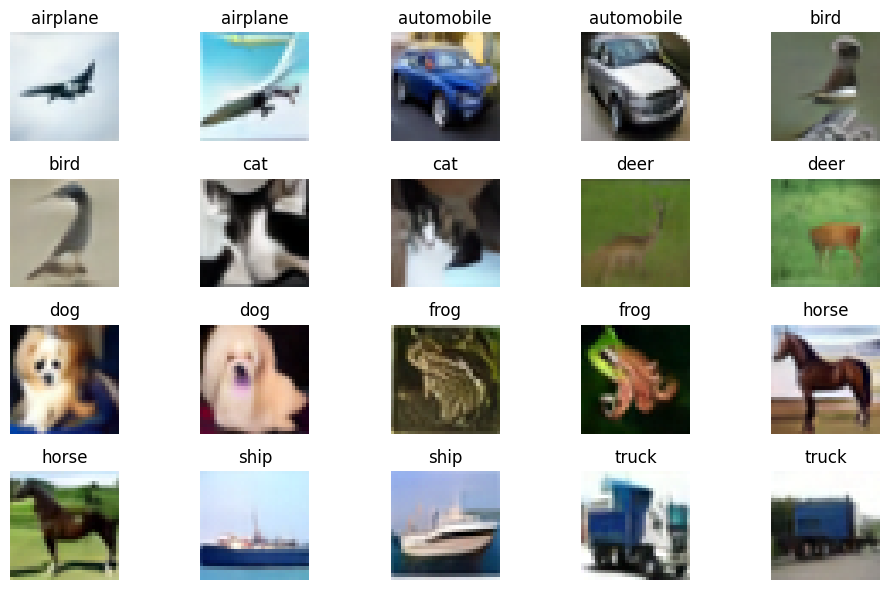

In [16]:
gen_and_plot_sample_imgs(
    model,
    dpmp_solver_quadratic,
    dataset_classes,
    cls_to_idx,
    _SAMPLE_CFG_SCALE,
    _NUM_SAMPLES,
)

In [17]:
FID_NUM_SAMPLES = 10000
FID_SAMPLE_BATCH_SIZE = 64

fid_calculator = fid_utils.FidCalculator(
    gt_loader=test_dataloader,
    device=torch_device,
    num_samples=FID_NUM_SAMPLES,
    batch_size=FID_SAMPLE_BATCH_SIZE,
)

Extracting GT data Inception features...
GT features: mu shape=(2048,), sigma shape=(2048, 2048)


In [18]:
fid_dict = dict()

fid_dict["euler"] = fid_calculator.compute_fid(
    model=model,
    device=torch_device,
    solver=euler_solver,
    num_classes=num_classes,
    imgsize=val_imgsize,
)

fid_dict["dpmp_linear"] = fid_calculator.compute_fid(
    model=model,
    device=torch_device,
    solver=dpmp_solver_linear,
    num_classes=num_classes,
    imgsize=val_imgsize,
)

fid_dict["dpmp_cosine"] = fid_calculator.compute_fid(
    model=model,
    device=torch_device,
    solver=dpmp_solver_cosine,
    num_classes=num_classes,
    imgsize=val_imgsize,
)

fid_dict["dpmp_quadratic"] = fid_calculator.compute_fid(
    model=model,
    device=torch_device,
    solver=dpmp_solver_quadratic,
    num_classes=num_classes,
    imgsize=val_imgsize,
)

Generating 10000 samples for FID computation...
Generating 10000 samples for FID computation...
Generating 10000 samples for FID computation...
Generating 10000 samples for FID computation...


In [19]:
for k, v in fid_dict.items():
    print(f"{k}: {v}")

euler: 25.475302288197376
dpmp_linear: 22.4740045480258
dpmp_cosine: 18.537269771462597
dpmp_quadratic: 26.26173905664851
